In [1]:
!pip install -q -U transformers peft accelerate
!pip install -q evaluate rouge_score sacrebleu scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 69.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 80.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.6 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import torch
from transformers import set_seed
import os
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    set_seed(seed) # Transformers specific seed

# Call this first!
seed_everything(42)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Blip2Processor, 
    Blip2ForConditionalGeneration, 
    TrainingArguments, 
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# 1. SETUP PATHS

In [3]:
DATASET_DIR = '/kaggle/input/datasets/kaidegast/vqarad'  
IMG_DIR = os.path.join(DATASET_DIR, 'VQA_RAD Image Folder')
TRAIN_CSV = os.path.join(DATASET_DIR, 'vqa_rad_train.csv')
VAL_CSV = os.path.join(DATASET_DIR, 'vqa_rad_valid.csv')
TEST_CSV = os.path.join(DATASET_DIR, 'vqa_rad_test.csv')

BASE_MODEL_ID = "Salesforce/blip2-opt-2.7b"
OUTPUT_DIR = "./vqarad-p100-final"

# Load Metrics
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")

# 2. DATASET CLASS 

In [4]:
class VQARADDataset(Dataset):
    def __init__(self, csv_file, img_dir, processor, mode='train'):
        self.img_dir = img_dir
        self.processor = processor
        self.mode = mode
        self.data = pd.read_csv(csv_file)
        
        # Ensure correct types
        self.data['question'] = self.data['question'].astype(str)
        self.data['answer'] = self.data['answer'].astype(str)
        # Fill missing answer_types with 'OPEN' just in case, though your CSV looks good
        if 'answer_type' in self.data.columns:
            self.data['answer_type'] = self.data['answer_type'].astype(str).str.upper()
        else:
            self.data['answer_type'] = 'OPEN'

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_id = row['img_id']      # e.g., "synpic54610.jpg"
        question = row['question']
        answer = row['answer']
        ans_type = row['answer_type'] # e.g., "CLOSED" or "OPEN"
        
        # --- 1. Load Image ---
        # Your CSV already has the extension, so we use it directly.
        img_path = os.path.join(self.img_dir, img_id)
        
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            # Fallback if path is wrong or file missing
            image = Image.new('RGB', (224, 224), color='black')

        # --- 2. Prompt Logic ---
        # If it's a CLOSED question, we explicitly ask for Yes/No.
        if ans_type == 'CLOSED':
            prompt = f"Question: {question} Answer yes or no. Answer:"
        else:
            prompt = f"Question: {question} Answer:"

        # --- 3. Return Logic ---
        if self.mode == 'train':
            # For training, we append the actual answer
            full_text = f"{prompt} {answer}"
            
            inputs = self.processor(
                images=image, text=full_text, return_tensors="pt", 
                padding="max_length", max_length=64, truncation=True
            )
            inputs = {k: v.squeeze(0) for k, v in inputs.items()}
            inputs['labels'] = inputs['input_ids'].clone()
            return inputs
        else:
            # For Test/Val, we just return the prompt and metadata
            inputs = self.processor(images=image, text=prompt, return_tensors="pt")
            inputs = {k: v.squeeze(0) for k, v in inputs.items()}
            
            inputs['ground_truth'] = answer
            inputs['answer_type'] = ans_type # Pass this for the metrics!
            return inputs

# 3. LOAD MODEL 

In [5]:
print("--- Loading Model ---")

processor = Blip2Processor.from_pretrained(
    BASE_MODEL_ID,
    use_fast=False
)
model = Blip2ForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID, 
    torch_dtype=torch.float16, # FP16 for P100
    device_map="auto"
)

model.gradient_checkpointing_enable()
model.enable_input_require_grads()

peft_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias="none", 
    task_type="CAUSAL_LM", target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


--- Loading Model ---


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


trainable params: 5,242,880 || all params: 3,750,004,736 || trainable%: 0.1398


# 4. TRAINING

In [6]:
train_dataset = VQARADDataset(TRAIN_CSV, IMG_DIR, processor, mode='train')
eval_dataset = VQARADDataset(VAL_CSV, IMG_DIR, processor, mode='train')

def collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.stack([x['labels'] for x in batch])
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=5,
    learning_rate=2e-4,
    fp16=True,
    eval_strategy="epoch",      # Updated from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=1,
    report_to="none",
    logging_steps=5
    
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collate_fn
)

print("\n--- Starting Training ---")
trainer.train()
model.save_pretrained(OUTPUT_DIR)


--- Starting Training ---


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,1.025026,0.439708
2,0.816484,0.409369
3,0.785044,0.403740
4,0.747307,0.398189
5,0.682483,0.398872


# 5. EVALUATION


   Running COMPREHENSIVE Evaluation on /kaggle/input/datasets/kaidegast/vqarad/vqa_rad_test.csv


100%|██████████| 225/225 [02:08<00:00,  1.76it/s]



----------------------------------------
RESULTS: CLOSED QUESTIONS (144 samples)
----------------------------------------
  Accuracy:                56.94%
  Precision (Weighted):    0.6163
  Recall (Weighted):       0.5694
  F1-Score (Weighted):     0.5589
  ROUGE-L:                 0.5764
  BLEU-2:                  0.5363

----------------------------------------
RESULTS: OPEN QUESTIONS (81 samples)
----------------------------------------
  Accuracy:                18.52%
  Precision (Weighted):    0.1539
  Recall (Weighted):       0.1852
  F1-Score (Weighted):     0.1556
  ROUGE-L:                 0.2774
  BLEU-2:                  0.0978

OVERALL DATASET RESULTS (225 samples)
  OVERALL Accuracy:        43.11%
  OVERALL Precision:       0.4585
  OVERALL Recall:          0.4311
  OVERALL F1 (Weighted):   0.4148
  OVERALL ROUGE-L:         0.4675

>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)


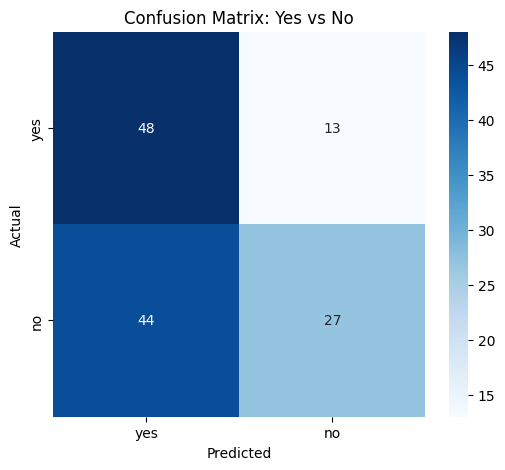

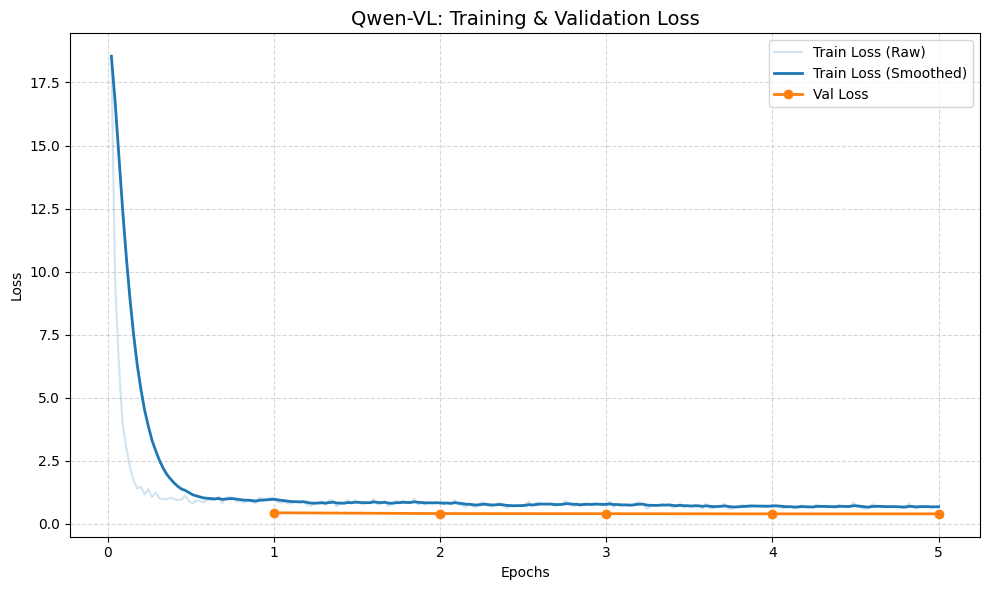

In [7]:
!pip install -q scikit-learn

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch

# Define text cleaner
def normalize_text(text):
    return text.lower().strip().replace('.', '')

def run_full_metrics_evaluation(csv_path):
    print(f"\n=======================================================")
    print(f"   Running COMPREHENSIVE Evaluation on {csv_path}")
    print(f"=======================================================")
    
    # 1. Setup Loader
    ds = VQARADDataset(csv_path, IMG_DIR, processor, mode='test')
    loader = DataLoader(ds, batch_size=1, shuffle=False)
    
    model.eval()
    
    # 2. Storage
    # Separate storage for detailed analysis
    data = {
        "CLOSED": {"preds": [], "refs": []},
        "OPEN":   {"preds": [], "refs": []}
    }
    
    # Global storage for Overall Metrics
    all_preds = []
    all_refs = []
    
    # 3. Inference Loop
    for batch in tqdm(loader):
        input_ids = batch.pop("input_ids").to("cuda")
        pixel_values = batch.pop("pixel_values").to("cuda")
        
        ground_truth = normalize_text(batch['ground_truth'][0])
        ans_type = batch['answer_type'][0]
        
        with torch.no_grad():
            output_ids = model.generate(
                input_ids=input_ids,
                pixel_values=pixel_values,
                max_new_tokens=10, 
                do_sample=False
            )
        
        # Decode
        pred = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
        pred = normalize_text(pred)
        
        # --- CLEANING LOGIC ---
        if "answer yes or no" in pred:
            pred = pred.replace("answer yes or no", "").strip()
        if "question" in pred:
            pred = pred.split("answer:")[-1].strip()
            
        # Store for Category Analysis
        if ans_type == 'CLOSED':
            data["CLOSED"]["preds"].append(pred)
            data["CLOSED"]["refs"].append(ground_truth)
        else:
            data["OPEN"]["preds"].append(pred)
            data["OPEN"]["refs"].append(ground_truth)
            
        # Store for Overall Analysis
        all_preds.append(pred)
        all_refs.append(ground_truth)

    # 4. Calculate & Print Metrics for each Category
    for category in ["CLOSED", "OPEN"]:
        preds = data[category]["preds"]
        refs = data[category]["refs"]
        
        if len(preds) == 0: continue
        
        print(f"\n" + "-"*40)
        print(f"RESULTS: {category} QUESTIONS ({len(preds)} samples)")
        print("-"*40)
        
        # Metrics
        acc = accuracy_score(refs, preds)
        
        # --- MODIFIED: Unpack Precision and Recall here ---
        precision, recall, f1, _ = precision_recall_fscore_support(
            refs, preds, average='weighted', zero_division=0
        )
        
        b2 = bleu_metric.compute(predictions=preds, references=[[r] for r in refs], max_order=2)
        rouge = rouge_metric.compute(predictions=preds, references=refs)

        # Print
        print(f"  Accuracy:                {acc*100:.2f}%")
        print(f"  Precision (Weighted):    {precision:.4f}") # Added
        print(f"  Recall (Weighted):       {recall:.4f}")    # Added
        print(f"  F1-Score (Weighted):     {f1:.4f}")
        print(f"  ROUGE-L:                 {rouge['rougeL']:.4f}")
        print(f"  BLEU-2:                  {b2['bleu']:.4f}")

    # 5. --- NEW SECTION: OVERALL METRICS ---
    print(f"\n" + "="*40)
    print(f"OVERALL DATASET RESULTS ({len(all_preds)} samples)")
    print("="*40)
    
    # Calculate Overall Accuracy
    overall_acc = accuracy_score(all_refs, all_preds)
    
    # --- MODIFIED: Calculate Overall Precision and Recall ---
    overall_prec, overall_rec, overall_f1, _ = precision_recall_fscore_support(
        all_refs, all_preds, average='weighted', zero_division=0
    )
    
    # Calculate Overall ROUGE-L
    overall_rouge = rouge_metric.compute(predictions=all_preds, references=all_refs)
    
    print(f"  OVERALL Accuracy:        {overall_acc*100:.2f}%")
    print(f"  OVERALL Precision:       {overall_prec:.4f}") # Added
    print(f"  OVERALL Recall:          {overall_rec:.4f}")    # Added
    print(f"  OVERALL F1 (Weighted):   {overall_f1:.4f}")
    print(f"  OVERALL ROUGE-L:         {overall_rouge['rougeL']:.4f}")

    # 6. Confusion Matrix (Closed-Ended Only)
    c_preds = data["CLOSED"]["preds"]
    c_refs = data["CLOSED"]["refs"]
    
    labels = ['yes', 'no']
    
    # Filter valid indices for plotting
    valid_indices = [i for i, r in enumerate(c_refs) if r in labels]
    filtered_refs = [c_refs[i] for i in valid_indices]
    filtered_preds = [c_preds[i] for i in valid_indices]
    
    final_refs = []
    final_preds = []
    for r, p in zip(filtered_refs, filtered_preds):
        if p in labels:
            final_refs.append(r)
            final_preds.append(p)
            
    if len(final_refs) > 0:
        print("\n>>> CONFUSION MATRIX (Closed-Ended: Yes vs No)")
        cm = confusion_matrix(final_refs, final_preds, labels=labels)
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix: Yes vs No')
        plt.show()

# Run the full evaluation
run_full_metrics_evaluation(TEST_CSV)

def plot_training_history(trainer, smooth_factor=0.8):
    log_history = trainer.state.log_history
    
    # 1. Extract Training Data (Loss)
    train_data = [e for e in log_history if 'loss' in e]
    train_epochs = [e['epoch'] for e in train_data]
    train_losses = [e['loss'] for e in train_data]
    
    # 2. Extract Validation Data (Loss)
    val_data = [e for e in log_history if 'eval_loss' in e]
    val_epochs = [e['epoch'] for e in val_data]
    val_losses = [e['eval_loss'] for e in val_data]

    # --- Smoothing Function ---
    def smooth(scalars, weight): 
        if not scalars: return []
        last = scalars[0]
        smoothed = []
        for point in scalars:
            smoothed_val = last * weight + (1 - weight) * point
            smoothed.append(smoothed_val)
            last = smoothed_val
        return smoothed

    smoothed_train_losses = smooth(train_losses, smooth_factor)

    # --- Start Plotting (Single Graph) ---
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_title('Qwen-VL: Training & Validation Loss', fontsize=14)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    
    # Plot Training Loss
    if train_losses:
        ax1.plot(train_epochs, train_losses, alpha=0.2, color='tab:blue', label='Train Loss (Raw)')
        ax1.plot(train_epochs, smoothed_train_losses, color='tab:blue', linewidth=2, label='Train Loss (Smoothed)')
    
    # Plot Validation Loss
    if val_losses:
        ax1.plot(val_epochs, val_losses, label='Val Loss', color='tab:orange', marker='o', linewidth=2)
    
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    plt.tight_layout()
    plt.show()

# Call the function
plot_training_history(trainer)

In [9]:
def run_hallucination_check(csv_path, num_test_samples=5, num_generations=5):
    import collections # Ensure this is imported
    print(f"\n=======================================================")
    print(f"   RUNNING HALLUCINATION CHECK (Consistency Test)")
    print(f"=======================================================")
    
    ds = VQARADDataset(csv_path, IMG_DIR, processor, mode='test')
    indices = random.sample(range(len(ds)), num_test_samples)
    
    model.eval()
    results_report = []

    for idx in indices:
        item = ds[idx]
        question_text = ds.data.iloc[idx]['question']
        ground_truth = item.pop('ground_truth')
        ans_type = item.pop('answer_type')
        
        # --- FIXED FOR BLIP-2 ---
        # Move inputs to GPU (BLIP-2 uses pixel_values and input_ids)
        input_ids = item['input_ids'].unsqueeze(0).to(model.device)
        pixel_values = item['pixel_values'].unsqueeze(0).to(model.device, dtype=torch.float16)
        
        generated_answers = []
        
        for _ in range(num_generations):
            with torch.no_grad():
                output_ids = model.generate(
                    input_ids=input_ids,
                    pixel_values=pixel_values,
                    max_new_tokens=15,
                    do_sample=True,      
                    temperature=0.8,     
                    top_p=0.9
                )
            
            # BLIP-2 decoding (it decodes the whole sequence including the prompt)
            gen_text = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
            
            # Clean prompt artifacts if they appear in output
            clean_text = normalize_text(gen_text)
            if "answer:" in clean_text:
                clean_text = clean_text.split("answer:")[-1].strip()
            
            generated_answers.append(clean_text)

        # Calculate Consistency
        counts = collections.Counter(generated_answers)
        most_common_answer, freq = counts.most_common(1)[0]
        consistency_score = (freq / num_generations) * 100
        
        if consistency_score == 100:
            status = "STABLE (High Confidence)"
        elif consistency_score >= 70:
            status = "Slightly Unstable"
        else:
            status = "POTENTIAL HALLUCINATION (Low Confidence)"

        results_report.append({
            "question": question_text,
            "ground_truth": ground_truth,
            "all_outputs": generated_answers,
            "consistency": f"{consistency_score}%",
            "status": status
        })

    for i, res in enumerate(results_report):
        print(f"\n[Sample {i+1}] Q: {res['question']}")
        print(f"  Expected: {res['ground_truth']}")
        print(f"  Model Answers: {res['all_outputs']}")
        print(f"  Consistency: {res['consistency']} -> {res['status']}")

# --- Execute the check ---
# This will pick 5 random images and ask the question 5 times for each.
run_hallucination_check(TEST_CSV, num_test_samples=10, num_generations=5)

The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.



   RUNNING HALLUCINATION CHECK (Consistency Test)


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.
The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when us


[Sample 1] Q: is pneumo intestinalis present
  Expected: yes
  Model Answers: ['yes', 'no', 'yes', 'yes', 'no']
  Consistency: 60.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 2] Q: is there a shift of midline structures
  Expected: no
  Model Answers: ['yes', 'no', 'no', 'yes', 'no']
  Consistency: 60.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 3] Q: are there clearly defined cardiac borders in this image
  Expected: yes
  Model Answers: ['no', 'yes', 'yes', 'yes', 'no']
  Consistency: 60.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 4] Q: what is abnormal about the pancreas
  Expected: enlarged
  Model Answers: ['calcification', 'it is enlarged', 'pancreas is enlarged', 'isometric swelling', 'calcification']
  Consistency: 40.0% -> POTENTIAL HALLUCINATION (Low Confidence)

[Sample 5] Q: which blood vessels are affected
  Expected: left aca and mca
  Model Answers: ['the cerebral arteries', 'main arteries', 'cerebral arteries', 'occipital arteries and 